# 0. 分布式训练

>这章都没怎么看懂，先留坑

为什么需要分布式训练？<br>
<br>
显存墙、算力墙。

| 并行策略 | 英文 | 缩写 | 切分维度 | 解决的核心问题 |
|---------|------|------|---------|--------------|
| 数据并行 | Data Parallelism | DP | Batch 维度 | 训练速度（吞吐量） |
| 张量并行 | Tensor Parallelism | TP | 权重矩阵维度 | 单层参数过大 |
| 流水线并行 | Pipeline Parallelism | PP | 模型层（深度）维度 | 层数过多 |
| 序列并行 | Sequence Parallelism | SP | 序列长度维度 | 长序列激活值过大 |
| 专家并行 | Expert Parallelism | EP | MoE 专家数维度 | MoE 模型专家过多 |


# 1. 数据并行（DP / DDP）

## DP

单进程多线程，GPU0 是 master。每次迭代：GPU0 取一个 batch → scatter 分发到各 GPU → 各 GPU 分别 forward → gather 回 GPU0 算 loss → scatter 回各 GPU 做 backward → reduce 梯度到 GPU0 → GPU0 更新参数后广播。

致命缺陷：

- GPU0 是瓶颈 ：负责 scatter/gather/reduce，负载远高于其他卡，显存占用更大
- 单进程受 Python GIL 限制，多线程无法充分利用多核
- 每次 forward 都要 gather 输出到 GPU0， 通信开销大
- 不支持多机

## DDP

多进程，每个 GPU 一个独立进程，地位平等。每个进程有自己的 DataLoader（DistributedSampler 保证数据不重叠），各自完成 forward → loss → backward，然后通过 Ring All-Reduce 在所有进程间同步梯度，最后各自独立 optimizer.step()。

# 2. 张量并行（TP）


张量并行是一种模型并行策略，核心思想是：把模型某一层的权重矩阵按行/列切分到多个 GPU 上，各 GPU 并行计算后再合并结果。

与数据并行（每卡完整模型）不同，TP 让每张卡只持有一部分参数，从而**突破单卡显存限制**。

**过程：**

$$Z = GeLU(X · A) · B$$

1. A 列并行
```
Y = X · A = X · [A₀ | A₁] = [X·A₀ | X·A₁] = [Y₀ | Y₁]

GPU0: Y0 = GeLU(X · A_left)     # 得到 Y 的左半列
GPU1: Y1 = GeLU(X · A_right)    # 得到 Y 的右半列
输出 Concat：Y = [Y₀ | Y₁]
```

2. B 行并行
```
Z = Y · B = [Y₀ | Y₁] · ┌──┐ = Y₀·B₀ + Y₁·B₁
                        │B₀│
                        │B₁│
                        └──┘
                        
GPU0: Z₀ = Y₀ × B₀
GPU1: Z₁ = Y₁ × B₁
输出 Concat：Z = Z₀ + Z₁
```

**优点：**
- 突破单卡显存限制 — TP 的核心价值。模型单层权重大到单卡放不下时（如大模型的超大 FFN），唯一能拆分单层的就是 TP。DP 需要整层放一张卡，PP 也只能切层不能切单层。
- 计算加速 — 矩阵乘法被切到多张卡上并行，理论上 N 卡接近 N 倍加速（在小通信开销场景下）。
- 通信量固定 — 每个 batch 的通信量只取决于 batch_size × seq_len × hidden_dim ，与模型参数量无关。模型再大，TP 也只传激活值，不传权重。
- 通信次数少 — 每个 Transformer Block 仅 2 次 All-Reduce（attention 输出 + FFN 输出），设计非常紧凑。
- 与 DP/PP 正交 — 三者可以任意组合，形成 3D 并行，互不冲突。

**缺点：**
1. 严重依赖高速互联 — All-Reduce 在每层 forward 和 backward 各做一遍，频率很高。必须靠 NVLink/NVSwitch（单机内 8 卡），一旦跨节点走 InfiniBand 甚至以太网， 性能断崖式下降 。
2. 通信与计算耦合紧密 — backward 时每算完一层梯度就要 All-Reduce，等通信完成才能继续。如果计算太快、通信太慢，大量时间在空等。
3. 代码侵入性高 — 不能像 DP 那样一行代码搞定。需要手动把 Transformer 每层的 MLP 和 Attention 拆成 f（列并行）和 g（行并行）版本，修改模型结构。
4. 只适合单机 — 大多数实践中 TP 度 ≤ 8（一台 8 卡机器），再大通信代价得不偿失。
5. 小模型反而变慢 — 权重矩阵本身很小的时候，通信开销可能超过计算节省，TP 倒亏。

| 场景 | 是否适合 TP |
|------|------------|
| 模型单层 > 单卡显存 | 必须用 |
| 大模型单机 8 卡训练 | 推荐 |
| 跨节点训练 | 不建议（用 DP 代替） |
| 小模型多卡 | 不要用 |
| 已有 DP + PP，还想提速 | 可以叠加 |


**TP 是用高速通信换显存，所以只在单机 NVLink 环境 + 大模型场景下才有价值。**

# 2. 流水线并行（PP）

流水线并行的思路是 按层切分模型 ：GPU0 管前几层，GPU1 管中间几层，GPU2 管最后几层，数据像流水线一样依次流过。

## GPipe（微批次流水线）

GPipe 的做法是把 M 个 micro-batch 的 forward 全部做完，再全部 backward：

```
GPU0: [F₀][F₁][F₂][F₃]........................[B₃][B₂][B₁][B₀]
GPU1:     [F₀][F₁][F₂][F₃]................[B₃][B₂][B₁][B₀]
GPU2:         [F₀][F₁][F₂][F₃]........[B₃][B₂][B₁][B₀]
GPU3:             [F₀][F₁][F₂][F₃][B₃][B₂][B₁][B₀]
```

优点：

- 调度简单
- 同步语义清晰
- 不存在参数版本不一致问题

缺点：

- 必须保存多个微批次的激活值
- 显存占用较高
- 流水线气泡较明显

## 1F1B（One Forward, One Backward）

不攒齐所有 forward 再一起 backward，而是 做完一个 forward 就尽快做一个 backward ：

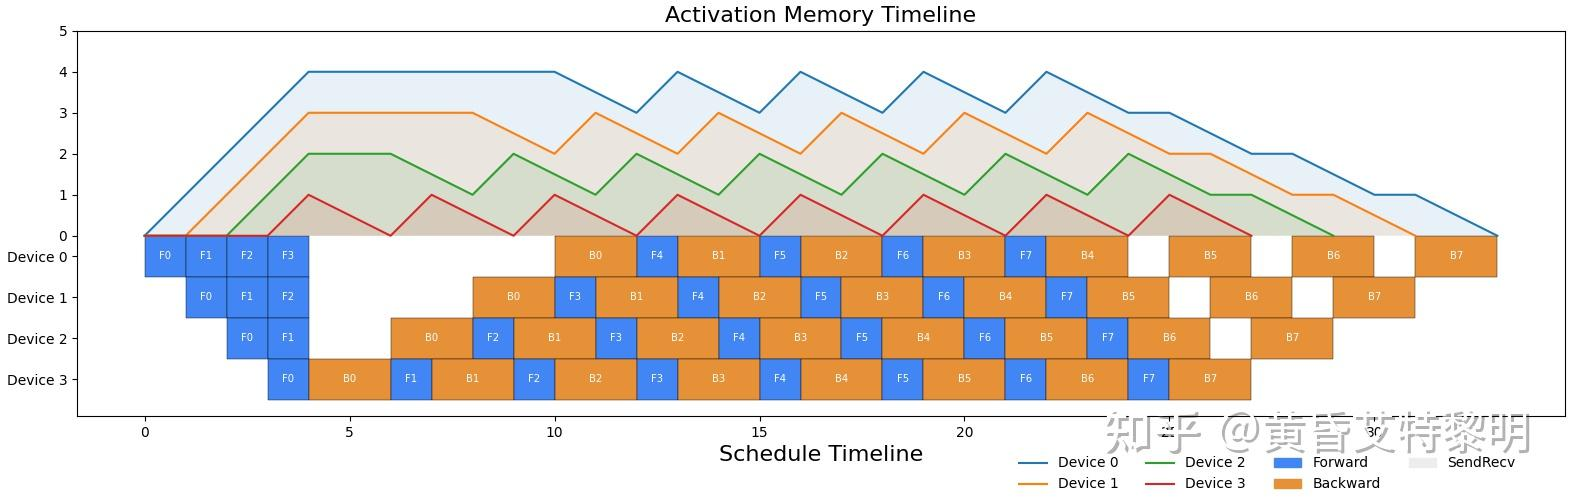

# 3. 序列并行（SP）

在 Transformer 模型中， Self-Attention 的计算复杂度和显存占用与序列长度呈平方关系 。当序列长度变得很长（如 128K、256K tokens），单个 GPU 无法容纳整个序列的激活值。

SP 的核心思路是： 将输入序列沿序列维度切分到多个设备上 ，每个设备只处理序列的一部分。

SP 通常与 TP 配合使用（在同一组 GPU 内），共同减少激活值。

# 4. ZeRO：消除优化器状态冗余

除数据并行训练中各设备上重复保存的优化器状态、梯度和模型参数 。

# Reference

1. [分布式训练基础：DP / TP / PP / SP / ZeRO](https://haozhe-xing.github.io/agent_learning/zh/chapter_agentic_rl/02b_distributed_training.html) <br>
2. [流水线并行可视化调度（Gpipe, 1F1B, Interleaved-1F1B, Zero Bubble）](https://zhuanlan.zhihu.com/p/1922398748941723463)